# **Import Libraries**

In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [142]:
df=pd.read_csv('student_performance.csv')# Load the dataset

In [143]:
df.head()# Display the first 5 rows of the dataset

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f


In [144]:
df.describe()# Get summary statistics of the dataset

,student_id,age,study_hours,attendance_percentage,math_score,science_score,english_score,overall_score
count,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,7493.04380,16.482760,4.253224,75.084084,63.785944,63.745320,63.681948,64.006172
std,4323.56215,1.703895,2.167541,14.373171,20.875262,20.970529,20.792693,18.932025
min,1.00000,14.000000,0.500000,50.000000,0.000000,0.000000,0.000000,14.500000
25%,3743.75000,15.000000,2.400000,62.800000,48.300000,48.200000,48.300000,49.000000
50%,7461.50000,16.000000,4.300000,75.100000,64.100000,64.100000,64.200000,64.200000
75%,11252.00000,18.000000,6.100000,87.500000,80.000000,80.000000,80.000000,79.000000
max,15000.00000,19.000000,8.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [145]:
df.info()# Get information about the dataset, including data types and missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             25000 non-null  int64  
 1   age                    25000 non-null  int64  
 2   gender                 25000 non-null  object 
 3   school_type            25000 non-null  object 
 4   parent_education       25000 non-null  object 
 5   study_hours            25000 non-null  float64
 6   attendance_percentage  25000 non-null  float64
 7   internet_access        25000 non-null  object 
 8   travel_time            25000 non-null  object 
 9   extra_activities       25000 non-null  object 
 10  study_method           25000 non-null  object 
 11  math_score             25000 non-null  float64
 12  science_score          25000 non-null  float64
 13  english_score          25000 non-null  float64
 14  overall_score          25000 non-null  float64
 15  fi

# **Preprocessing**

In [146]:
df.isnull().sum()# Check for missing values in each column

,0
student_id,0
age,0
gender,0
school_type,0
parent_education,0
study_hours,0
attendance_percentage,0
internet_access,0
travel_time,0
extra_activities,0


In [147]:
df.duplicated().sum()# Check for duplicate rows in the dataset

np.int64(10000)

In [148]:
df.drop_duplicates(inplace=True)# Remove duplicate rows from the dataset

In [149]:
df.drop("student_id", axis=1, inplace=True)# Drop the 'student_id' column as it is not useful for prediction

In [150]:
df.duplicated().sum()# Check for duplicate rows in the dataset

np.int64(0)

# **Encoding**

In [151]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

binary_cols = ['gender', 'internet_access', 'extra_activities']

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

In [152]:
df = pd.get_dummies(df, columns=[
    'school_type',
    'parent_education',
    'travel_time',
    'study_method'
], drop_first=True)# One-hot encode categorical variables and drop the first category to avoid multicollinearity

In [153]:
df['final_grade'] = le.fit_transform(df['final_grade'])# Encode the target variable

# **Splitting**

In [154]:
X = df.drop("final_grade", axis=1)
y = df["final_grade"]

In [155]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **Featue Selection**

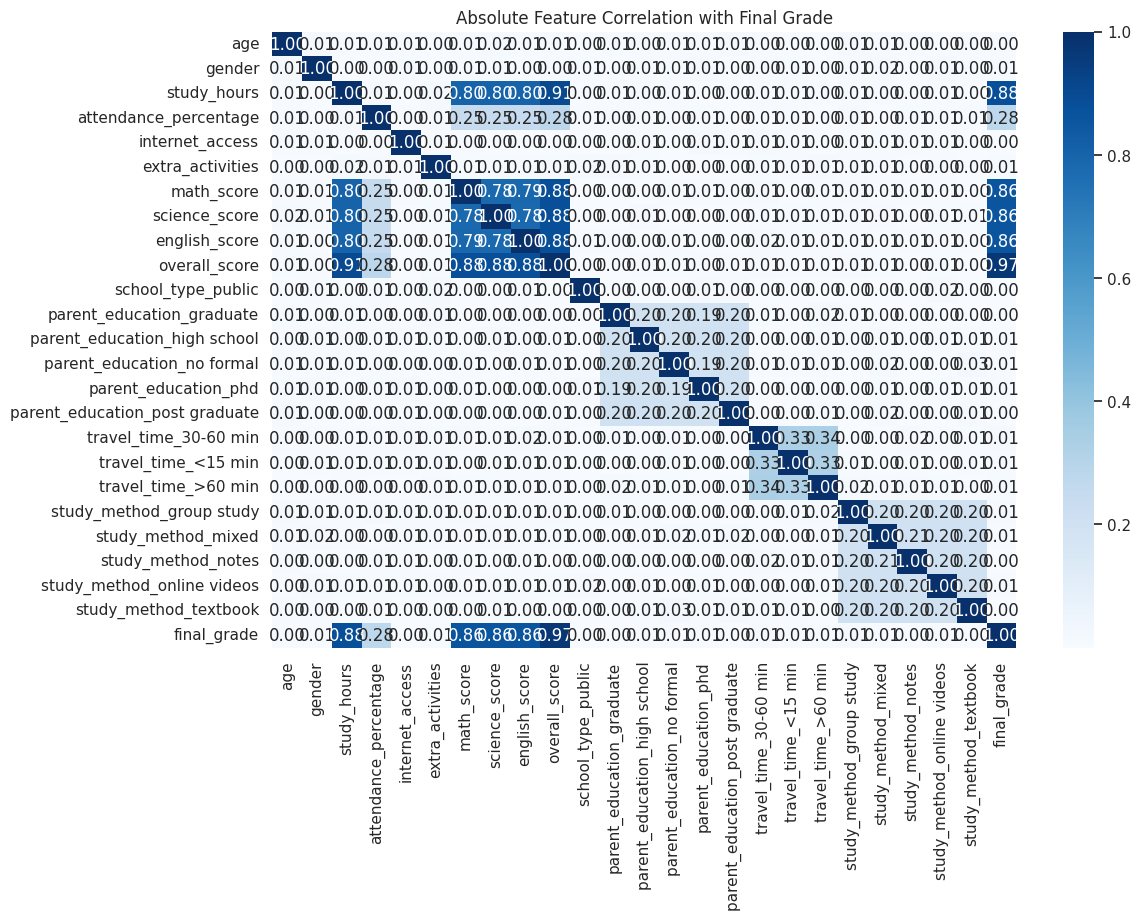

In [156]:
plt.figure(figsize=(12, 8))

correlation_matrix = X_train.join(y_train).corr().abs()
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt=".2f")

plt.title("Absolute Feature Correlation with Final Grade")
plt.show()


In [157]:
Top_features = correlation_matrix.index[correlation_matrix['final_grade'] > 0.1].tolist()# Select features with absolute correlation greater than 0.1 with the target variable

print("Top Features ARE:", Top_features)

Top Features ARE: ['study_hours', 'attendance_percentage', 'math_score', 'science_score', 'english_score', 'overall_score', 'final_grade']


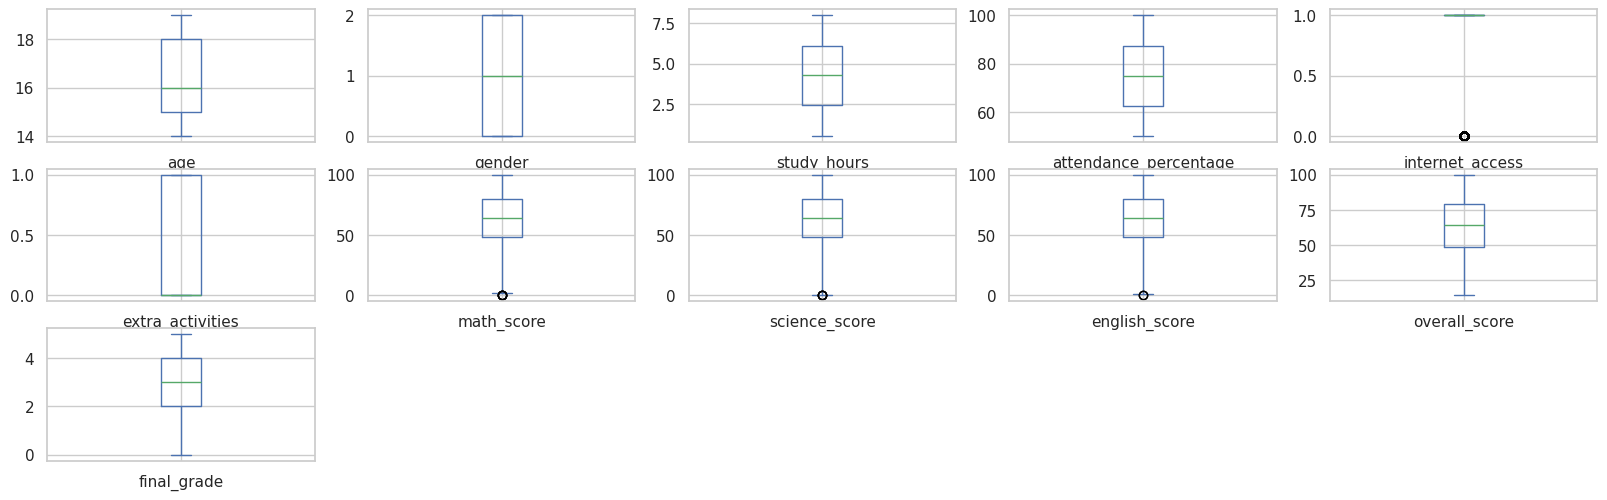

In [158]:
df.plot(kind='box', subplots=True, layout=(5,5), figsize=(20,10))
plt.show()

# **Scaling**

In [159]:
if 'final_grade' in Top_features:
    Top_features.remove('final_grade')

In [160]:

X_train_final = X_train[Top_features]
X_test_final = X_test[Top_features]


In [161]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

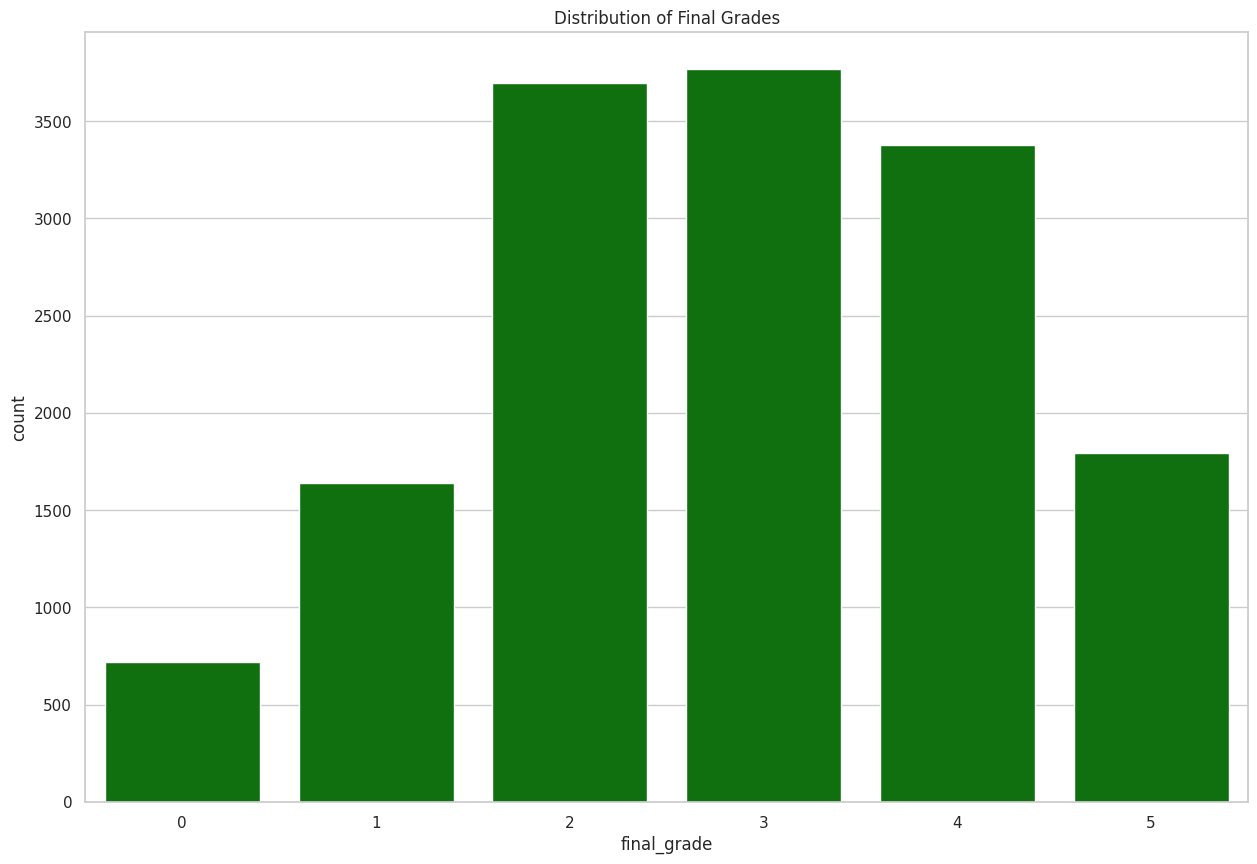

In [162]:
sns.countplot(x='final_grade', data=df,color="green")
plt.title('Distribution of Final Grades')
plt.show()

# **1 - Support Vector Machine**

In [163]:
##1--> SVM
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_model = SVC()
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

svm_acc = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", svm_acc)

SVM Accuracy: 0.962


# **2 - K-Nearest Neighbors**

In [164]:
#2-->KNN
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

knn_acc = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy:", knn_acc)

KNN Accuracy: 0.8746666666666667


# **3 - Random Forest**

In [165]:
#3--> Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

rf_acc = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.996


# **4 - DecisionTree**

In [166]:
#4--->DecisionTree
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier()
dt_model.fit(X_train_scaled, y_train)

y_pred_dt = dt_model.predict(X_test_scaled)

dt_acc = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.9956666666666667


# **5 - MLP**

In [167]:
#5-->MLP
from sklearn.neural_network import MLPClassifier

nn_model = MLPClassifier(max_iter=1000)
nn_model.fit(X_train_scaled, y_train)

y_pred_nn = nn_model.predict(X_test_scaled)

nn_acc = accuracy_score(y_test, y_pred_nn)
print("Neural Network Accuracy:", nn_acc)

Neural Network Accuracy: 0.9923333333333333


# **6 - LogisticRegression**

In [168]:
#6-->LogisticRegression
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
lr_acc = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.9463333333333334


# **ALL RESULTS**

In [169]:
results = {
    "SVM": svm_acc,
    "KNN": knn_acc,
    "Random Forest": rf_acc,
    "Decision Tree": dt_acc,
    "Neural Network": nn_acc,
    "Logistic Regression": lr_acc
}

best_model = max(results, key=results.get)

print(f"\n Best Model: {best_model} with accuracy = {results[best_model]:.3f}")


 Best Model: Random Forest with accuracy = 0.996


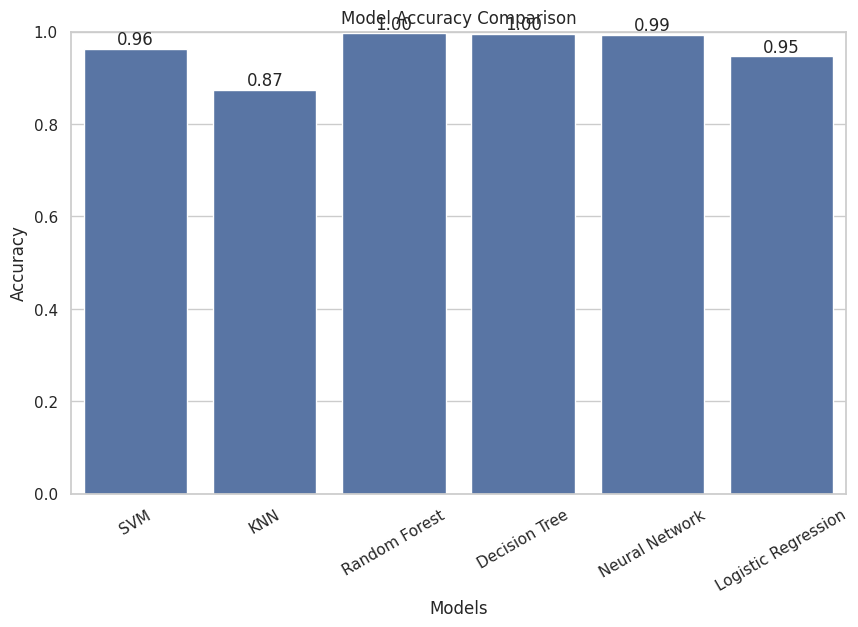

In [170]:
models = ['SVM', 'KNN', 'Random Forest', 'Decision Tree', 'Neural Network', 'Logistic Regression']
accuracies = [svm_acc, knn_acc, rf_acc, dt_acc, nn_acc, lr_acc]

plt.figure(figsize=(10,6))
sns.barplot(x=models, y=accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0,1)


for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.xticks(rotation=30)
plt.show()


# **Evaluation** **Metrics**



In [171]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

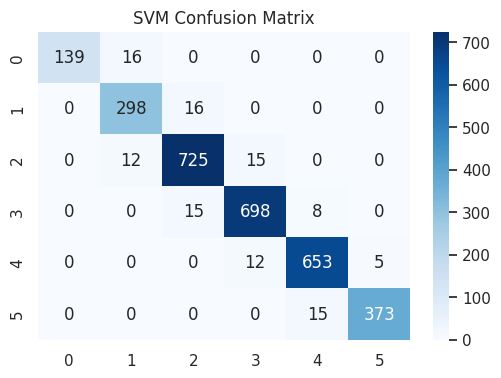

In [172]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues')
plt.title('SVM Confusion Matrix')
plt.show()




In [173]:
print("SVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

SVM Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95       155
           1       0.91      0.95      0.93       314
           2       0.96      0.96      0.96       752
           3       0.96      0.97      0.97       721
           4       0.97      0.97      0.97       670
           5       0.99      0.96      0.97       388

    accuracy                           0.96      3000
   macro avg       0.96      0.95      0.96      3000
weighted avg       0.96      0.96      0.96      3000



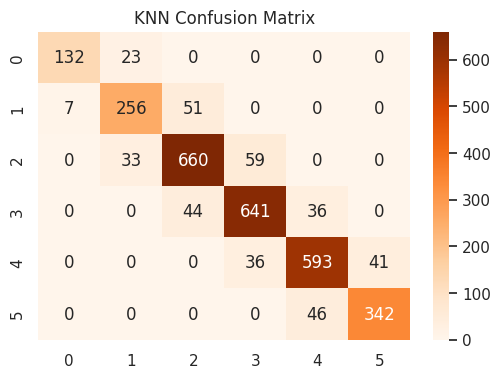

In [174]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Oranges')
plt.title('KNN Confusion Matrix')
plt.show()


In [175]:
print("KNN Classification Report:")
print(classification_report(y_test, y_pred_knn))

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.85      0.90       155
           1       0.82      0.82      0.82       314
           2       0.87      0.88      0.88       752
           3       0.87      0.89      0.88       721
           4       0.88      0.89      0.88       670
           5       0.89      0.88      0.89       388

    accuracy                           0.87      3000
   macro avg       0.88      0.87      0.87      3000
weighted avg       0.88      0.87      0.87      3000



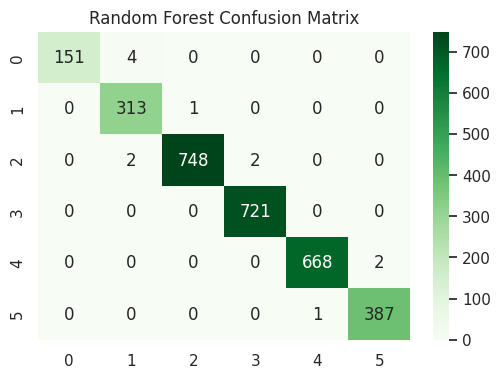

In [176]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest Confusion Matrix')
plt.show()



In [177]:
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99       155
           1       0.98      1.00      0.99       314
           2       1.00      0.99      1.00       752
           3       1.00      1.00      1.00       721
           4       1.00      1.00      1.00       670
           5       0.99      1.00      1.00       388

    accuracy                           1.00      3000
   macro avg       1.00      0.99      0.99      3000
weighted avg       1.00      1.00      1.00      3000



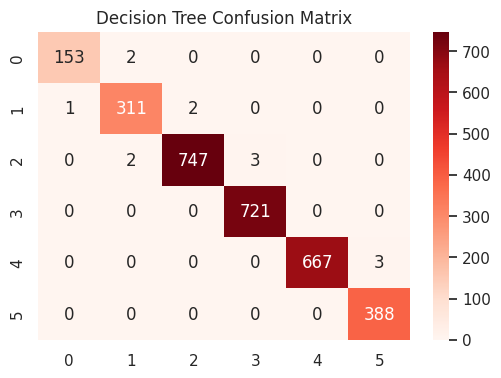

In [178]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Reds')
plt.title('Decision Tree Confusion Matrix')
plt.show()

In [179]:
print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       155
           1       0.99      0.99      0.99       314
           2       1.00      0.99      1.00       752
           3       1.00      1.00      1.00       721
           4       1.00      1.00      1.00       670
           5       0.99      1.00      1.00       388

    accuracy                           1.00      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       1.00      1.00      1.00      3000



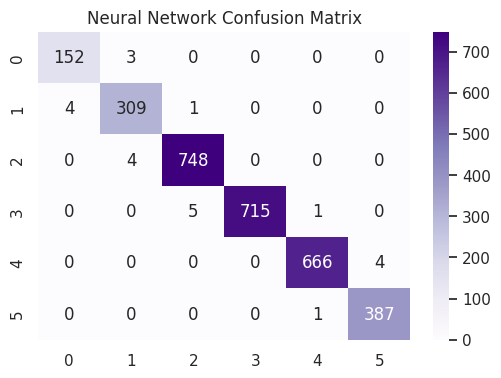

In [180]:
cm_nn = confusion_matrix(y_test, y_pred_nn)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Purples')
plt.title('Neural Network Confusion Matrix')
plt.show()

In [181]:
print("Neural Network Classification Report:")
print(classification_report(y_test, y_pred_nn))

Neural Network Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       155
           1       0.98      0.98      0.98       314
           2       0.99      0.99      0.99       752
           3       1.00      0.99      1.00       721
           4       1.00      0.99      1.00       670
           5       0.99      1.00      0.99       388

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000



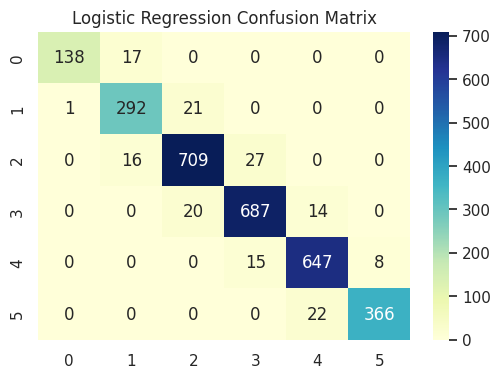

In [182]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Logistic Regression Confusion Matrix')
plt.show()



In [183]:
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.89      0.94       155
           1       0.90      0.93      0.91       314
           2       0.95      0.94      0.94       752
           3       0.94      0.95      0.95       721
           4       0.95      0.97      0.96       670
           5       0.98      0.94      0.96       388

    accuracy                           0.95      3000
   macro avg       0.95      0.94      0.94      3000
weighted avg       0.95      0.95      0.95      3000

